<a href="https://colab.research.google.com/github/lilith-witch/bird-maps/blob/main/projekt_python.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##**Vizualizace tahu různých druhů ptáků**

Neccessary import.

In [ ]:
import geopandas
import pandas as pd
import matplotlib as plt
from matplotlib.animation import FuncAnimation
import json
#import shapely
import datetime
import seaborn
from functools import partial







https://geojson-maps.kyd.au/


https://www.jla-data.net/cze/faunisticke-ctverce/

In [ ]:

maps_file = "custom.geo.json"
maps = pd.read_json(maps_file)

def extract_country_data(maps, country_name):
    index = False
    for i in range(len(maps['features'])):
      name = maps['features'][i]['properties']['name']
      if name == country_name:
        index = i
    if index is False:
      print("Country not found")

    else:
      print(index)
      with open(sought_country+'.json', 'w+') as f:
        country_json = {
            "type": "FeatureCollection",
            "features": [maps['features'][index]]
        }
        json.dump(country_json, f)

sought_country="Czechia"
extract_country_data(maps, sought_country)



5


In [ ]:
base_file = sought_country+'.json'
base = geopandas.read_file(base_file)
grid_file = "kfme.wgs84.geojson"
ctverce = geopandas.read_file(grid_file, mask = base)



<Axes: >

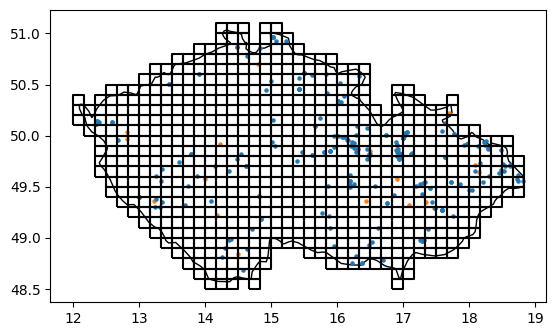

In [ ]:

filename = "data.csv"
data = pd.read_csv(filename, sep= ';')
data.columns

base.to_crs(epsg = 3035) ## jsme-li hnidopiši

chosen_columns = ['Date','Latitude','Longitude','District','Region','Rarity','SpeciesID','SpeciesName','ItemLatitude','ItemLongitude','TagUncertain']
data = data[chosen_columns]

if type(data['Date'][0]) == str:
  data['Date'] = pd.to_datetime(data['Date'])

species = pd.Series(data['SpeciesID']).value_counts()[:10] # at maximum 10 species

colors = dict(zip(species.keys(),plt.color_sequences['tab10'][:len(species.keys())]))


base_ax = base.plot(color='white', edgecolor='black')

for specie in species.keys()[::-1]:
  data_points = data[data['SpeciesID'] == specie]
  geometry = geopandas.points_from_xy(data_points['Longitude'], data_points['Latitude'])
  mapa_bodu = geopandas.GeoDataFrame(data_points, geometry=geometry)
  mapa_bodu.plot(ax=base_ax, marker='o', color=colors[specie], markersize=5)
ctverce.boundary.plot(ax = base_ax, edgecolor = 'black')


##Preprocessing


##Animations

In [ ]:
def frequency_map(selected):
            geometry = geopandas.points_from_xy(selected['Longitude'], selected['Latitude'])
            mapa_bodu = geopandas.GeoDataFrame(selected, geometry=geometry)
            points =[[name, mapa_bodu.geometry.within(polygon).sum()] for (name, polygon) in zip(ctverce.id, ctverce.geometry)
              ]
            n_points = pd.DataFrame(data = points, columns = ['id', 'counts'])
            #merged = ctverce.merge(n_points, on = 'id')
            return n_points

def generate_frame_observed(frame_date : datetime.datetime ):

        base_ax.clear() ##upravit normalizaci
        selected = data_specie[data_specie['Date'] == frame_date]
        n_points = frequency_map(selected)
        merged = ctverce.merge(n_points, on = 'id')
        merged.plot(ax = base_ax,column = 'counts', cmap = 'viridis', vmax = vmax )
        base_ax.set_title(f" Pozorování - {frame_date.date()}", fontsize=15)
        base_ax.set_axis_off()


def generate_frame_cumulative(frame_date : datetime.datetime ):

        base_ax.clear() ##upravit normalizaci
        selected = data_specie[data_specie['Date'] <= frame_date]
        n_points = frequency_map(selected)
        merged = ctverce.merge(n_points, on = 'id')
        merged.plot(ax = base_ax,column = 'counts', cmap = 'viridis', vmax = vmax )
        base_ax.set_title(f" Kumulace - {frame_date.date()}", fontsize=15)
        base_ax.set_axis_off()


def generate_gif(species_id:int , opt : str, start: datetime.datetime = data['Date'].min() , end : datetime.datetime= data['Date'].max()):
    if start > end:
      end = start
    if end > data['Date'].max():
        end = data['Date'].max()
    if start < data['Date'].min():
        start = data['Date'].min()
    if opt == 'o':
      func = generate_frame_observed
    elif opt == 'c':
      func = generate_frame_cumulative

    dates = pd.date_range(start,end)

    global data_specie
    data_specie= data[data['SpeciesID'] == species_id]
    global vmax
    if opt == 'c':
      n_points = frequency_map(data_specie)
      vmax = n_points['counts'].max()

    if opt == 'o':
      vmax = 0
      for date in dates:
          n_points = frequency_map(data_specie[data_specie['Date'] == date])
          if n_points['counts'].max() > vmax:
            vmax = n_points['counts'].max()


    global fig, base_ax
    fig, base_ax = plt.pyplot.subplots(figsize=(10, 10))




    anim = FuncAnimation(fig, func, frames=dates, interval=1000, repeat=True)
    anim.save(f"animation{species_id}_{start}_{end}_{opt}.gif")


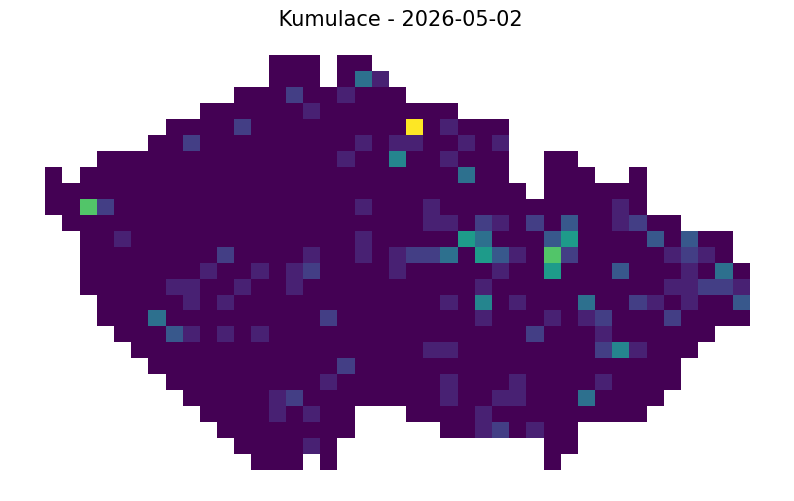

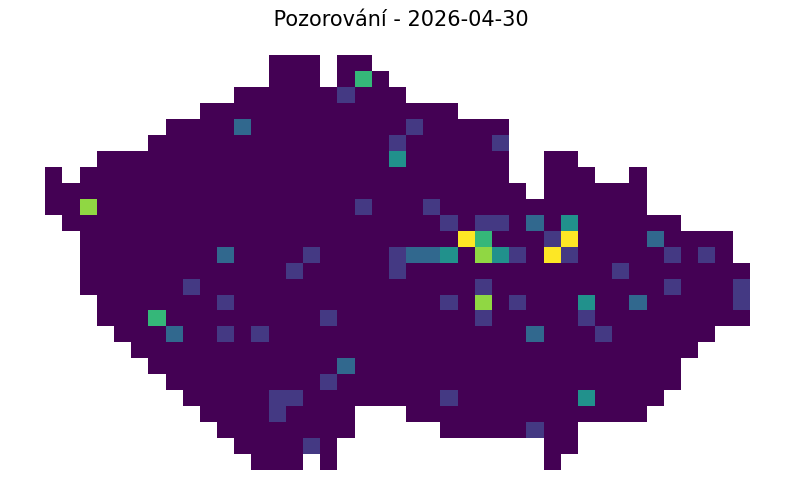

In [ ]:
generate_gif(312,'c')
generate_gif(312,'o')

# časové řady

AttributeError: module 'matplotlib' has no attribute 'subplots'

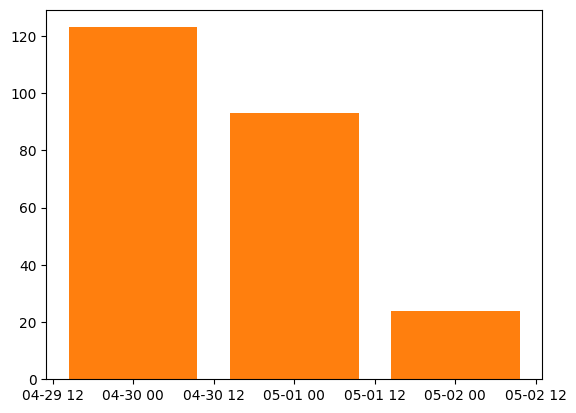

In [ ]:
for id in species.keys()[::-1]:
  help = data[data['SpeciesID'] == id]
  n_points = pd.Series.value_counts(help['Date']).sort_index()

  plt.pyplot.bar(n_points.index, n_points.values )
## sloupcový graf.
## odmazat ten čas
## přeškálovat osy

fig, ax = plt.subplots()
bottom = np.zeros(3)

for sex, sex_count in sex_counts.items():
    p = ax.bar(species, sex_count, width, label=sex, bottom=bottom)
    bottom += sex_count

    ax.bar_label(p, label_type='center')

ax.set_title('Number of penguins by sex')
ax.legend()

plt.show()


# hustota na km

# Korelace druhů